# Erste Verarbeitungsschritte (Schritt für Schritt)

Ziel: Wir bauen aus den Perseus-TEI-XML-Dateien ein kleines, reproduzierbares **Mini-Dataset** (Metadaten-Tabelle), das du in den nächsten Sitzungen weiterverwenden kannst.

**Voraussetzung**
- Dieses Notebook liegt in einem Ordner.
- Daneben gibt es einen Ordner `data/`.
- In `data/` liegen die XML-Dateien (Perseus).

Am Ende hast du:
- `outputs/cicero_letters_metadata_mini.csv`
- erste Statistiken und mehrere einfache Grafiken


## 0) Imports und Grundeinstellungen

Wir verwenden:
- `lxml` zum Lesen der XML-Dateien (XPath ist damit sehr bequem)
- `pandas` für Tabellen
- `matplotlib` für erste Grafiken


In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
from lxml import etree

pd.set_option('display.max_colwidth', 120)


## 1) Dateien finden

Wir sammeln alle XML-Dateien aus `data/`.


In [5]:
data_dir = Path('/home/phillip/Documents/uzh/teaching/ss-2026/cicero-digital/content/data')
xml_files = sorted(data_dir.glob('*.xml'))
len(xml_files), [p.name for p in xml_files]

(4,
 ['phi0474.phi056.perseus-lat1-ad-familiares.xml',
  'phi0474.phi057.perseus-lat1-ad-atticum.xml',
  'phi0474.phi058.perseus-lat1-ad-quintum.xml',
  'phi0474.phi059.perseus-lat1-ad-brutum.xml'])

Wenn hier `0` steht, stimmt die Ordnerstruktur nicht. Kontrolliere: `data/` liegt wirklich neben dem Notebook.


## 2) Eine XML-Datei öffnen und TEI-Namespace verstehen

Viele TEI-Dateien haben einen **Default-Namespace** (z.B. `http://www.tei-c.org/ns/1.0`).
Wenn man XPath benutzt, muss man diesen Namespace meist explizit angeben.

Wir schauen uns das kurz an einer Datei an.


In [6]:
parser = etree.XMLParser(recover=True, huge_tree=True)

test_doc = etree.parse(str(xml_files[0]), parser)
root = test_doc.getroot()

root.tag, root.nsmap

('{http://www.tei-c.org/ns/1.0}TEI', {None: 'http://www.tei-c.org/ns/1.0'})

Du siehst hier typischerweise in `nsmap` einen Eintrag für `None`. Das ist der Default-Namespace.
Wir erzeugen daraus einen Namespace-Mapper wie `{'tei': 'http://www.tei-c.org/ns/1.0'}`.


In [7]:
def get_tei_ns(root) -> dict:
    """Gibt einen Namespace-Mapper für TEI zurück (falls Default-Namespace gesetzt ist)."""
    ns = root.nsmap.get(None)
    return {'tei': ns} if ns else {}

ns = get_tei_ns(root)
ns

{'tei': 'http://www.tei-c.org/ns/1.0'}

## 3) Was ist ein Brief im XML?

In den Perseus-Dateien sind Briefe meist als `div` mit `subtype="letter"` kodiert.
Wir zählen einmal, wie viele wir in der Testdatei finden.


In [8]:
letter_divs = root.xpath(".//tei:div[@subtype='letter']", namespaces=ns) if ns else root.xpath(".//*[@subtype='letter' and local-name()='div']")
len(letter_divs)

431

## 4) Ein einzelner Brief als Objekt

Wir schauen uns einen Brief an und lesen einfache Attribute aus.
- `n` ist oft die Briefnummer.
- Der zugehörige Buch-`div` (subtype `Book`) steht weiter oben in der Hierarchie.


In [15]:
one = letter_divs[1]  # --> wir schauen uns den zweiten Brief an

# Briefnummer
one.get('n')

'2'

In [16]:
# Buchdiv als Vorfahr suchen
book_div = one.xpath("ancestor::tei:div[@subtype='Book'][1]", namespaces=ns) if ns else one.xpath("ancestor::*[local-name()='div' and @subtype='Book'][1]")
book_n = book_div[0].get('n') if book_div else None
book_n

'1'

## 5) Textbausteine: Datumszeile, Anrede, Datum

Im TEI werden die Datumszeile und die Anrede oft als `seg` mit `rend` markiert:
- `seg[@rend='dateline']`
- `seg[@rend='salute']`

Das Datum selbst steht manchmal in `date[@when='...']`.


In [17]:
def norm_ws(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()

def text_of_first(nodes):
    if not nodes:
        return None
    return norm_ws(' '.join(nodes[0].itertext()))

dateline = text_of_first(one.xpath(".//tei:seg[@rend='dateline']", namespaces=ns)) if ns else text_of_first(one.xpath(".//*[local-name()='seg' and @rend='dateline']"))
salute = text_of_first(one.xpath(".//tei:seg[@rend='salute']", namespaces=ns)) if ns else text_of_first(one.xpath(".//*[local-name()='seg' and @rend='salute']"))
date_el = one.xpath(".//tei:date[1]", namespaces=ns) if ns else one.xpath(".//*[local-name()='date'][1]")
date_when = date_el[0].get('when') if date_el else None

dateline, salute, date_when

('Scr. Romae a. d. xvi Kal. Febr. a. 698 (56).',
 'M. CICERO S.D. P. LENTVLO PROCOS.',
 None)

## 6) Absender und Empfänger heuristisch aus der Anrede

Das ist bewusst eine **Heuristik**. Sie ist nützlich für erste Schritte (z.B. Netzwerke), aber sie ist nicht automatisch philologisch perfekt.

Beispiele:
- `Cicero Bruto salutem` → Absender `Cicero`, Empfänger `Bruto`
- `M. Cicero S.D. P. Lentulo procos.` → Absender `M. Cicero`, Empfänger `P. Lentulo procos`


In [18]:
def extract_sender_recipient_from_salute(salute):
    """Heuristik für:
    - 'Cicero Bruto salutem' -> ('Cicero', 'Bruto')
    - 'M. Cicero S.D. P. Lentulo procos.' -> ('M. Cicero', 'P. Lentulo procos')
    """
    if not salute:
        return None, None

    s = norm_ws(str(salute)).replace('"', '').replace("'", '')
    # Schlusswort salutem am Ende entfernen
    s = re.sub(r'\b(salutem)\b\.?\s*$', '', s, flags=re.IGNORECASE).strip()

    # Trenner S.D. (salutem dicit)
    m = re.search(r'\bS\s*\.?\s*D\s*\.?\b', s, flags=re.IGNORECASE)
    if m:
        sender = norm_ws(s[:m.start()]) or None
        recipient = norm_ws(s[m.end():])
        recipient = re.sub(r'^[\s\.,;:]+', '', recipient)
        recipient = re.sub(r'[\s\.,;:]+$', '', recipient)
        recipient = recipient or None
        return sender, recipient

    parts = s.split()
    if len(parts) < 2:
        return None, None
    return parts[0], parts[1]

extract_sender_recipient_from_salute(salute)

('M. CICERO', 'P. LENTVLO PROCOS')

## 7) Jahr aus `date_when` ableiten

Wenn `date_when` z.B. `-0043` ist, machen wir daraus ein Integer-Jahr.
Wenn das Format anders ist oder fehlt, geben wir `None` zurück.


In [20]:
def parse_year(date_when):
    if not date_when:
        return None
    s = str(date_when).strip()
    return int(s) if re.match(r'^-?\d{1,4}$', s) else None

print(parse_year(date_when))

None


## 8) Aus einem Brief eine Zeile (Dictionary) bauen

Jetzt bauen wir aus den einzelnen Teilen eine strukturierte Zeile.


In [21]:
sender, recipient = extract_sender_recipient_from_salute(salute)

row = {
    'corpus': 'TEST',
    'book_n': book_n,
    'letter_n': one.get('n'),
    'date_when': date_when,
    'year': parse_year(date_when),
    'dateline': dateline,
    'salute': salute,
    'sender': sender,
    'recipient': recipient,
}

row

{'corpus': 'TEST',
 'book_n': '1',
 'letter_n': '2',
 'date_when': None,
 'year': None,
 'dateline': 'Scr. Romae a. d. xvi Kal. Febr. a. 698 (56).',
 'salute': 'M. CICERO S.D. P. LENTVLO PROCOS.',
 'sender': 'M. CICERO',
 'recipient': 'P. LENTVLO PROCOS'}

## 9) Jetzt richtig: Alle Dateien und alle Briefe verarbeiten

Das ist der zentrale Schritt. Wir loopen über alle XML-Dateien und über alle Briefe darin.
Am Ende entsteht eine grosse Liste von Zeilen.


In [22]:
def corpus_label_from_filename(p: Path) -> str:
    name = p.name.lower()
    if 'ad-familiares' in name:
        return 'ad_familiares'
    if 'ad-atticum' in name:
        return 'ad_atticum'
    if 'ad-quintum' in name:
        return 'ad_quintum_fratrem'
    if 'ad-brutum' in name:
        return 'ad_m_brutum'
    return p.stem

rows = []

for path in xml_files:
    corpus = corpus_label_from_filename(path)
    doc = etree.parse(str(path), parser)
    root = doc.getroot()
    ns = get_tei_ns(root)

    letter_divs = root.xpath(".//tei:div[@subtype='letter']", namespaces=ns) if ns else root.xpath(".//*[@subtype='letter' and local-name()='div']")

    for ld in letter_divs:
        book_div = ld.xpath("ancestor::tei:div[@subtype='Book'][1]", namespaces=ns) if ns else ld.xpath("ancestor::*[local-name()='div' and @subtype='Book'][1]")
        book_n = book_div[0].get('n') if book_div else None
        letter_n = ld.get('n')

        dateline = text_of_first(ld.xpath(".//tei:seg[@rend='dateline']", namespaces=ns)) if ns else text_of_first(ld.xpath(".//*[local-name()='seg' and @rend='dateline']"))
        salute = text_of_first(ld.xpath(".//tei:seg[@rend='salute']", namespaces=ns)) if ns else text_of_first(ld.xpath(".//*[local-name()='seg' and @rend='salute']"))
        date_el = ld.xpath(".//tei:date[1]", namespaces=ns) if ns else ld.xpath(".//*[local-name()='date'][1]")
        date_when = date_el[0].get('when') if date_el else None

        sender, recipient = extract_sender_recipient_from_salute(salute)

        rows.append({
            'corpus': corpus,
            'book_n': book_n,
            'letter_n': letter_n,
            'date_when': date_when,
            'year': parse_year(date_when),
            'dateline': dateline,
            'salute': salute,
            'sender': sender,
            'recipient': recipient,
        })

len(rows)

930

## 10) DataFrame bauen und anschauen


In [23]:
df = pd.DataFrame(rows)
df.head(10)

,corpus,book_n,letter_n,date_when,year,dateline,salute,sender,recipient
0,ad_familiares,1,1,-0056,-56.0,Scr. Romae Id. Ian. a. u. c. 698 (a. Chr. 56) .,None,None,None
1,ad_familiares,1,2,None,NaN,Scr. Romae a. d. xvi Kal. Febr. a. 698 (56).,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
2,ad_familiares,1,3,-0056,-56.0,Scr. Romae medio mense Ian. a. 698 (56) .,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
3,ad_familiares,1,4,None,NaN,Scr. Romae circiter xv Kal. Febr. a. 698 (56).,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
4,ad_familiares,1,5a,-0056,-56.0,Scr. Romae circiter Non. Febr. a. 698 (56) .,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
5,ad_familiares,1,5b,None,NaN,Scr. Romae paulo post vi Id. Febr. a. 698 (56).,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
6,ad_familiares,1,6,-0056,-56.0,"Scr. Romae mense ut videtur, Mart. a. 698 (56) .",M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
7,ad_familiares,1,7,-0056,-56.0,Scr. Romae exeunte mense Quint. a. 698 (56) .,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
8,ad_familiares,1,8,-0055,-55.0,Scr. Romae mense Ian. a. 699 (55) .,M. CICERO S. D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS
9,ad_familiares,1,9,-0054,-54.0,Scr. Romae mense Dec. a. 700 (54) .,M. CICERO S. D. LENTVLO IMP.,M. CICERO,LENTVLO IMP


## 11) Mini-Dataset exportieren

Das ist die Datei, die du später wieder einlesen kannst.


In [24]:
out_dir = Path('outputs')
out_dir.mkdir(exist_ok=True)

mini_cols = ['corpus','book_n','letter_n','sender','recipient','date_when','year','dateline']
mini = df[mini_cols].copy()

mini_path = out_dir / 'cicero_letters_metadata_mini.csv'
mini.to_csv(mini_path, index=False)
mini_path

PosixPath('outputs/cicero_letters_metadata_mini.csv')

## 12) Erste Statistiken

Wir machen drei einfache Checks:
1. Briefe pro Korpus
2. Anteil Briefe mit Datum (`date_when`) pro Korpus
3. Missingness: Welche Felder fehlen wie oft?


In [25]:
letters_per_corpus = df.groupby('corpus').size().sort_values(ascending=False)
letters_per_corpus

corpus
ad_atticum            446
ad_familiares         431
ad_quintum_fratrem     27
ad_m_brutum            26
dtype: int64

In [26]:
dated_share = df['date_when'].notna().groupby(df['corpus']).mean().sort_values(ascending=False)
dated_share

corpus
ad_quintum_fratrem    0.740741
ad_familiares         0.561485
ad_m_brutum           0.461538
ad_atticum            0.327354
Name: date_when, dtype: float64

In [27]:
missingness = mini.isna().mean().sort_values(ascending=False)
missingness

date_when    0.548387
year         0.548387
book_n       0.479570
recipient    0.037634
sender       0.001075
corpus       0.000000
letter_n     0.000000
dateline     0.000000
dtype: float64

## 13) Grafiken

Viele Grafiken sind gut, aber sie sollen einfach bleiben.
Wir machen hier:
- Balken: Briefe pro Korpus
- Balken: Anteil datierter Briefe
- Balken: fehlende Werte (Missingness)
- Histogramm: Jahresverteilung (falls genügend Daten)


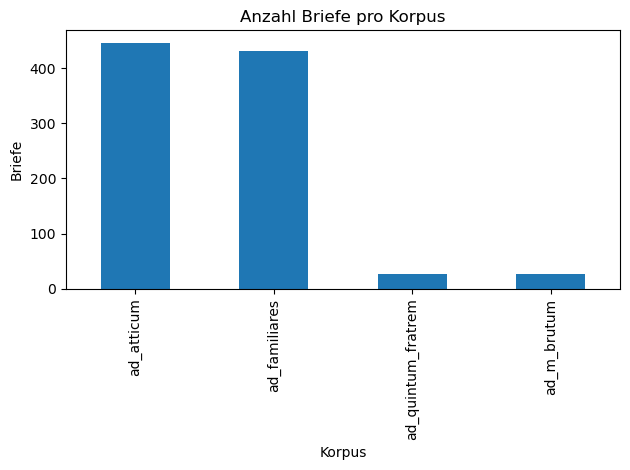

In [28]:
plt.figure()
letters_per_corpus.plot(kind='bar')
plt.title('Anzahl Briefe pro Korpus')
plt.xlabel('Korpus')
plt.ylabel('Briefe')
plt.tight_layout()
plt.show()

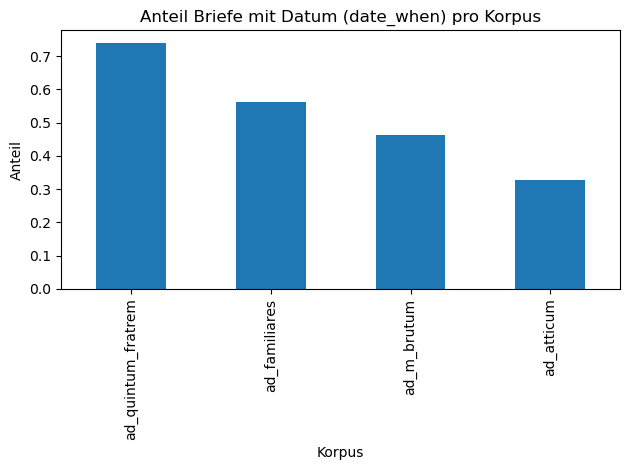

In [29]:
plt.figure()
dated_share.plot(kind='bar')
plt.title('Anteil Briefe mit Datum (date_when) pro Korpus')
plt.xlabel('Korpus')
plt.ylabel('Anteil')
plt.tight_layout()
plt.show()

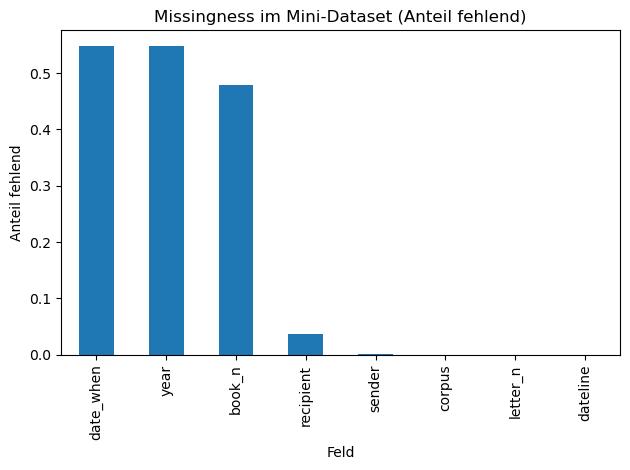

In [30]:
plt.figure()
missingness.plot(kind='bar')
plt.title('Missingness im Mini-Dataset (Anteil fehlend)')
plt.xlabel('Feld')
plt.ylabel('Anteil fehlend')
plt.tight_layout()
plt.show()

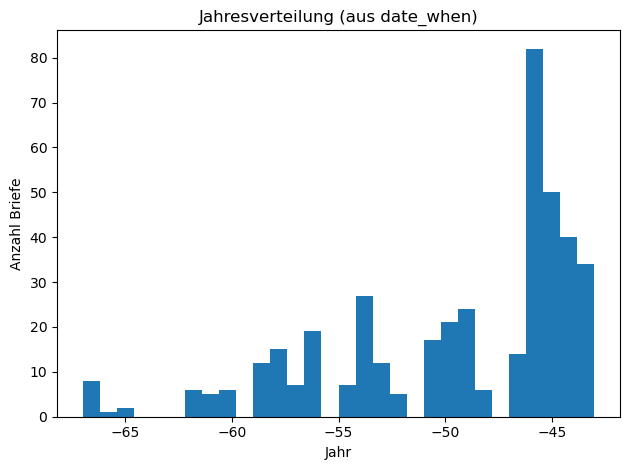

In [31]:
years = df['year'].dropna()
if len(years) > 0:
    plt.figure()
    years.plot(kind='hist', bins=30)
    plt.title('Jahresverteilung (aus date_when)')
    plt.xlabel('Jahr')
    plt.ylabel('Anzahl Briefe')
    plt.tight_layout()
    plt.show()
else:
    print('Keine Jahre vorhanden (year ist überall leer).')

## 14) Kleine Reflexion (für die Datenkritik)

Notiere dir (kurz):
- Welche Felder sind stabil (fast immer vorhanden)?
- Welche Felder fehlen oft?
- Was bedeutet das für spätere Analysen (z.B. Zeitverläufe, Netzwerke, Orte)?

Genau hier wird sichtbar: Briefe sind eine Datenbasis, aber diese Datenbasis ist durch Überlieferung und Edition geprägt.
